### Install package to access HBP Collab v2 storage

### Load packages

In [1]:
import os
import json
import ebrains_drive

### Create 'client' to connect to storage

In [2]:
client = ebrains_drive.connect('shailesh', os.getenv("HBP_PASS"))

### List all Collabs

In [3]:
list_repos =  client.repos.list_repos()

In [4]:
list_repos

[ebrains_drive.repo.Repo(id='24c75bc7-abca-4923-9fb1-9825ebb706c4', name='My Library'),
 ebrains_drive.repo.Repo(id='f0916ecd-4c2b-412c-be78-e1bbbee8998c', name='Demo'),
 ebrains_drive.repo.Repo(id='6a9c4a56-be4a-4157-b302-f29ad6b91b22', name='.ipynb_checkpoints'),
 ebrains_drive.repo.Repo(id='641438fa-6200-43eb-87b1-2c35b40da912', name='SGA3 WP6 internal'),
 ebrains_drive.repo.Repo(id='0fee1620-062d-4643-865b-951de1eee355', name='Shailesh-Testing'),
 ebrains_drive.repo.Repo(id='48b9b198-8d7f-4eb2-8f6e-fb5ccc9f3c28', name='M24 Progress Reports & M24 Review'),
 ebrains_drive.repo.Repo(id='f0509367-6fac-4409-960e-384106390644', name='HBP Event Participation'),
 ebrains_drive.repo.Repo(id='c11f95c0-59fd-428f-b02e-2238566c8499', name='Technical Coordination'),
 ebrains_drive.repo.Repo(id='b6d6a596-3799-408f-8f49-f6dc6a6e894a', name='SGA3 T4.13 HLST Internal'),
 ebrains_drive.repo.Repo(id='b20c54d0-13eb-4f6f-890f-0125a1f77133', name='Innovation'),
 ebrains_drive.repo.Repo(id='42fa6fcf-3804-

### Filter Collabs by name

In [5]:
list_repos_name = client.repos.get_repos_by_name("Shailesh-Testing")

In [6]:
list_repos_name

[ebrains_drive.repo.Repo(id='0fee1620-062d-4643-865b-951de1eee355', name='Shailesh-Testing'),
 ebrains_drive.repo.Repo(id='a1030721-2414-4609-9067-31c44af4edb3', name='Shailesh-Testing'),
 ebrains_drive.repo.Repo(id='0fee1620-062d-4643-865b-951de1eee355', name='Shailesh-Testing')]

### Filter Collabs by URL - preferable!

In [7]:
my_repo = client.repos.get_repo_by_url("shailesh-testing")

In [8]:
my_repo

ebrains_drive.repo.Repo(id='0fee1620-062d-4643-865b-951de1eee355', name='Shailesh-Testing')

In [9]:
my_repo = client.repos.get_repo_by_url("https://wiki.ebrains.eu/bin/view/Collabs/shailesh-testing")

In [10]:
my_repo

ebrains_drive.repo.Repo(id='0fee1620-062d-4643-865b-951de1eee355', name='Shailesh-Testing')

### Explore a specific Collab's storage (directories)

In [11]:
base_dir = my_repo.get_dir('/')

In [12]:
base_contents = base_dir.ls()
base_contents

[SeafDir[repo=0fee16, path=/d1, entries=1],
 SeafDir[repo=0fee16, path=/Dir1, entries=6],
 SeafFile[repo=0fee16, path=/CA1_pyr_cACpyr_mpg141017_a1-2_idC_20190328143405.zip, size=20124834],
 SeafFile[repo=0fee16, path=/data.json, size=9],
 SeafFile[repo=0fee16, path=/fig1.jpg, size=73727],
 SeafFile[repo=0fee16, path=/sample-latest.csv, size=884],
 SeafFile[repo=0fee16, path=/test1.txt, size=8]]

In [13]:
base_contents[0]

SeafDir[repo=0fee16, path=/d1, entries=1]

In [14]:
my_repo.get_dir("/d1")

SeafDir[repo=0fee16, path=/d1, entries=1]

In [15]:
my_dir = my_repo.get_dir("/d1/d2/dir2_1")

In [16]:
my_dir.ls()

[SeafDir[repo=0fee16, path=/d1/d2/dir2_1/data_sub2_1, entries=1],
 SeafFile[repo=0fee16, path=/d1/d2/dir2_1/data2_1.json, size=9]]

### Read a file

#### Example 1: text file

In [17]:
my_file1 = my_repo.get_file("/test1.txt")

In [18]:
my_file1

SeafFile[repo=0fee16, path=/test1.txt, size=8]

In [19]:
my_file1.get_content()

b'testing\n'

In [20]:
print(type(my_file1.get_content()))

<class 'bytes'>


In [21]:
print(my_file1.get_content().decode("utf-8"))
print(type(my_file1.get_content().decode("utf-8")))

testing

<class 'str'>


#### Example 2: json file

In [22]:
my_file2 = my_repo.get_file("/d1/d2/dir2_1/data2_1.json")
my_file2

SeafFile[repo=0fee16, path=/d1/d2/dir2_1/data2_1.json, size=9]

In [23]:
my_file2.get_content()

b'{"a" : 1}'

In [24]:
print(my_file2.get_content().decode("utf-8") )
print(type(my_file2.get_content().decode("utf-8")))

{"a" : 1}
<class 'str'>


In [25]:
print(json.loads(my_file2.get_content()))
print(type(json.loads(my_file2.get_content())))

{'a': 1}
<class 'dict'>


#### Example 3: image file

In [26]:
my_file3 = my_repo.get_file("/fig1.jpg")

In [27]:
my_file3.get_content()

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x01\x00x\x00x\x00\x00\xff\xdb\x00C\x00\x04\x02\x03\x06\x03\x03\x03\x04\x06\x07\x0e\n\x05\x04\x03\x02\x04\x05\x0e\x0f\x15\x17\x11\x10\x0c\x06\x04\x04\x03\x06\x0c\x0f\x12\r\x18\x1e\x1c\x19\x0e\x17\x0f\x08\n\t\x0e\x13\x14\x1a\x19\x1e\x19\x1a\x10\x0c\x11\x14\x0f\x17\x19\x13\x15\x1c\x19\x18\xff\xdb\x00C\x01\x04\x04\x06\x18\x0b\x04\x06\x18\x18\x18\x18\x18\x18\x10\x05\x06\x0e\x18\x18\x18\x18\x18\x18\x18\x18\x18\x10\x0b\x06\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\x18\xff\xc4\x01\xa2\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\x01\x00\x03\x01\x01\x01\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\x

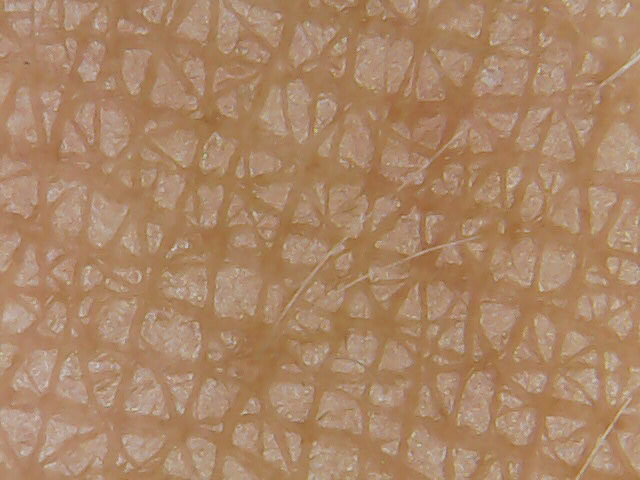

In [28]:
!pip install --upgrade --quiet pip
!pip install --upgrade --quiet Pillow

import sys
from PIL import Image
from io import BytesIO
from IPython.display import display

stream = BytesIO(my_file3.get_content())
display(Image.open(stream))

### Create a new directory

In [29]:
new_dir = base_dir.mkdir("temp_dir")

In [30]:
base_dir.ls()

[SeafDir[repo=0fee16, path=/d1, entries=1],
 SeafDir[repo=0fee16, path=/Dir1, entries=6],
 SeafDir[repo=0fee16, path=/temp_dir, entries=0],
 SeafFile[repo=0fee16, path=/CA1_pyr_cACpyr_mpg141017_a1-2_idC_20190328143405.zip, size=20124834],
 SeafFile[repo=0fee16, path=/data.json, size=9],
 SeafFile[repo=0fee16, path=/fig1.jpg, size=73727],
 SeafFile[repo=0fee16, path=/sample-latest.csv, size=884],
 SeafFile[repo=0fee16, path=/test1.txt, size=8]]

In [31]:
new_dir.ls()

[]

### Upload a file to a directory

In [32]:
with open("./temp_file1.txt", 'w+') as f:
    f.write("Temp file for demo!")

In [33]:
new_file1 = new_dir.upload_local_file("./temp_file1.txt")

In [34]:
new_dir.ls()

[SeafFile[repo=0fee16, path=/temp_dir/temp_file1.txt, size=19]]

In [35]:
print(new_file1.get_content())

b'Temp file for demo!'
